In [ ]:

import os

# Your Kaggle credentials
os.environ['KAGGLE_USERNAME'] = 'mrutunjayasenapati'
os.environ['KAGGLE_KEY'] = 'KGAT_02e50883fa1520465bb2f03194c31f43'

# Install kaggle
os.system('pip install kaggle -q')

# Download dataset
os.system('kaggle datasets download -d gti-upm/leapgestrecog')
print("✅ Download complete!")

✅ Download complete!


In [ ]:
import os
files = os.listdir('/content/')
print(files)

['.config', 'leapgestrecog.zip', 'sample_data']


In [ ]:
import zipfile
import os

print("Extracting... please wait")
with zipfile.ZipFile('/content/leapgestrecog.zip', 'r') as z:
    z.extractall('/content/gesture_data/')

print("✅ Extracted!")
print(os.listdir('/content/gesture_data/'))

Extracting... please wait
✅ Extracted!
['leapgestrecog', 'leapGestRecog']


In [ ]:
import numpy as np
import cv2
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

IMG_SIZE = 64
data = []
labels = []

base_dir = '/content/gesture_data/leapGestRecog/'
subjects = os.listdir(base_dir)

print("Loading images...")
for subject in subjects:
    subject_path = os.path.join(base_dir, subject)
    if not os.path.isdir(subject_path):
        continue
    gestures = os.listdir(subject_path)
    for gesture in gestures:
        gesture_path = os.path.join(subject_path, gesture)
        if not os.path.isdir(gesture_path):
            continue
        images = os.listdir(gesture_path)[:200]
        for img_name in images:
            img_path = os.path.join(gesture_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img.flatten())
            labels.append(gesture)

X = np.array(data)
y = np.array(labels)
print(f"✅ Done! Total images: {len(X)}")
print(f"Gesture classes: {np.unique(y)}")

Loading images...
✅ Done! Total images: 20000
Gesture classes: ['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']


In [ ]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2, random_state=42)

print("Training SVM...")
print("Please wait 3-5 minutes...")
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)
print("✅ SVM Trained!")

Training SVM...
Please wait 3-5 minutes...
✅ SVM Trained!


In [ ]:
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("=" * 40)
print("     MODEL PERFORMANCE RESULTS")
print("=" * 40)
print(f"  Accuracy : {acc*100:.2f}%")
print("=" * 40)
print(classification_report(y_test, y_pred,
      target_names=le.classes_))

     MODEL PERFORMANCE RESULTS
  Accuracy : 99.80%
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       404
         02_l       0.99      1.00      0.99       409
      03_fist       1.00      1.00      1.00       366
04_fist_moved       1.00      1.00      1.00       392
     05_thumb       1.00      1.00      1.00       377
     06_index       1.00      1.00      1.00       403
        07_ok       1.00      0.99      1.00       418
08_palm_moved       0.99      1.00      1.00       417
         09_c       1.00      0.99      1.00       404
      10_down       1.00      1.00      1.00       410

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



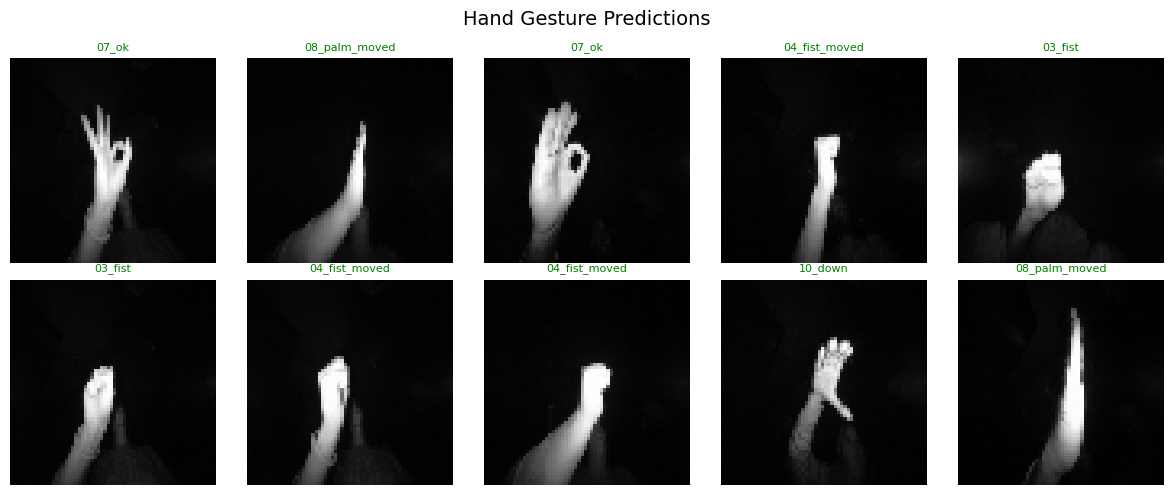

✅ Green=Correct  Red=Wrong


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Hand Gesture Predictions', fontsize=14)

for i, ax in enumerate(axes.flat):
    img = X_test[i]
    orig = scaler.inverse_transform([img])[0]
    orig = orig.reshape(IMG_SIZE, IMG_SIZE)
    ax.imshow(orig, cmap='gray')
    pred_label = le.classes_[y_pred[i]]
    true_label = le.classes_[y_test[i]]
    color = 'green' if y_test[i]==y_pred[i] else 'red'
    ax.set_title(f'{pred_label}', color=color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("✅ Green=Correct  Red=Wrong")

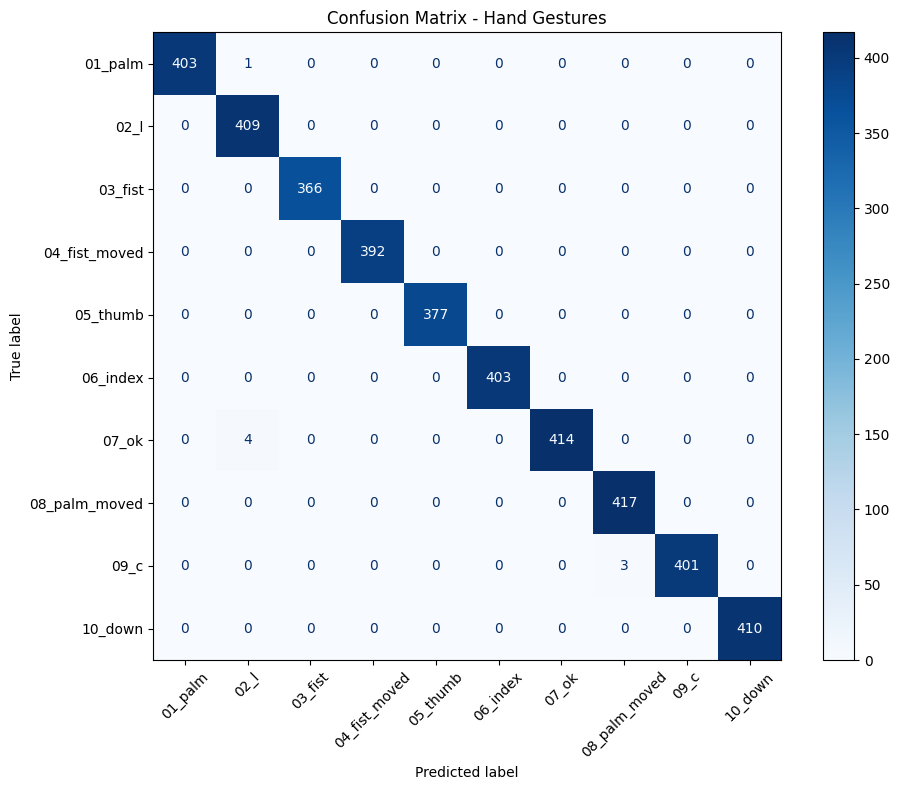

✅ Confusion Matrix done!


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues',
          xticks_rotation=45)
plt.title('Confusion Matrix - Hand Gestures')
plt.tight_layout()
plt.show()
print("✅ Confusion Matrix done!")